# Анализ клиентов инвестиционной платформы Т-Банка

### Исследовательский вопрос
**Как характеристики клиентов связаны с их биржевой активностью и как выглядит идеальный клиент для бизнеса?**

### Краткое описание
В работе проведён анализ данных клиентов инвестиционной платформы:
- Исследовательский анализ и очистка данных
- Агрегация до уровня клиента и генерация признаков
- Кластеризация клиентов (KMeans)
- Определение сегмента идеальных клиентов
- Сравнение идеальных и обычных клиентов
- Формулировка продуктовых гипотез

### Основные выводы
- Выделен сегмент идеальных клиентов (21,8% выборки)
- Идеальные клиенты имеют в десятки раз более высокие обороты и портфель
- Сильно чаще используют срочный рынок, маржу и статус квалифицированного инвестора
- Поведенческие характеристики важнее социально-демографических
- Сформулированы гипотезы по развитию Пульса, продвинутых инструментов и онбординга

In [67]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

sns.set_style('whitegrid')
pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.2f}'.format)

seed = 42
np.random.seed(seed)
warnings.simplefilter(action='ignore', category=FutureWarning)


In [68]:
df = pd.read_csv("./invest_db.csv", sep=";", decimal = ",", parse_dates=["date", "invest_utilization_dt"])

print(f"Размер датасета: {df.shape}")
print(f"\nТипы данных:\n{df.dtypes}")
print(f"\nДубликатов: {df.duplicated().sum()}")

Размер датасета: (458370, 51)

Типы данных:
id                                   int64
date                        datetime64[us]
age                                  int64
education_level_cd                     str
marital_status_cd                      str
children_cnt                       float64
monthly_income_amt                 float64
invest_utilization_dt       datetime64[us]
forts_flg                            int64
margin_status_flg                    int64
qualified_investor_flg               int64
in_payment_rub_amt                 float64
out_payment_rub_amt                float64
uncovered_position_amt             float64
turnover_rus_bon_amt               float64
turnover_rus_sec_amt               float64
turnover_forts_amt                 float64
turnover_cur_amt                   float64
turnover_etf_amt                   float64
turnover_fnd_amt                   float64
turnover_opt_amt                   float64
turnover_ore_prc_amt               float64
turnover_o

In [69]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(1)
pd.concat([missing, missing_pct], axis=1, keys=['count', '%']).sort_values('%', ascending=False)

,count,%
lon_balance_amt,309867,67.60
education_level_cd,224910,49.10
marital_status_cd,191340,41.70
ccr_balance_amt,167028,36.40
monthly_income_amt,103230,22.50
children_cnt,48060,10.50
comments,19320,4.20
posts,19320,4.20
reacts,19320,4.20
reads,19320,4.20


In [70]:
print(f"{["Не на", "На"][df.groupby("id")["id"].count().nunique()]} каждого из {df["id"].nunique()} пользователей приходится {df["date"].nunique()} ежедневных записей")
print(f"С {df["date"].min().date()} по {df["date"].max().date()}")

На каждого из 5093 пользователей приходится 90 ежедневных записей
С 2024-02-01 по 2024-04-30


In [71]:
p = set(df[df["posts"].isna()]["id"])
c = set(df[df["comments"].isna()]["id"])
rc = set(df[df["reacts"].isna()]["id"])
rd = set(df[df["reads"].isna()]["id"])
print(f"{["Не для всех", "Для всех"][int(p == c and p == rc and p == rd)]} пользователей с пропущенным соц-сетевым полем также пропущены остальные")

Для всех пользователей с пропущенным соц-сетевым полем также пропущены остальные


In [72]:
p = set(df[df["posts"].isna()]["id"])
c = set(df[df["comments"].isna()]["id"])
rc = set(df[df["reacts"].isna()]["id"])
rd = set(df[df["reads"].isna()]["id"])
print(f"Зарегистрированные в Пульсе пользователи без активности: {len(p&c&rc&rd)}")

Зарегистрированные в Пульсе пользователи без активности: 290


Синхронный NaN по всем 4-м полям говорит о том, что либо система не зафиксировала профиль в Пульсе, либо агрегат записывается как null при отсутствии активности, что скорее всего не так - 290 человек также не активны, но зарегистрированы в системе. Заполню пропуски нулями и создам флаг наличия аккаунта в сети.

В балансах NaN означает отсутствие конкретного типа продукта (нет кредита на заёмные средства, нет кредитной/дебетовой карты). Предположение: отсутствие записи по остатку баланса равен нулевому балансу.

**Соцдем:**
- Для категорий (education, marital): заполню отдельным значением 'UNK' (Unknown).
- Обычно отсутствие информации о детях приравнивается к 0.
- Доход нельзя заполнять средним/медианой или нулем. Лучше оставить NaN для анализа с поддержкой пропусков или восстанавливать через мл-модель, а в EDA анализировать как отдельную категорию.

In [73]:
# Соцсети - заменяем nan на 0 и добавляем флаг
social_cols = ["posts", "comments", "reacts", "reads"]
df["has_pulse_activity"] = df["posts"].notna().astype(int)
df[social_cols] = df[social_cols].fillna(0)

# Финансовые балансы — заменяем NaN на 0
balance_cols = ["lon_balance_amt", "ccr_balance_amt", "cor_balance_amt"]
df[balance_cols] = df[balance_cols].fillna(0)

df["education_level_cd"] = df["education_level_cd"].fillna("UNK")
df["marital_status_cd"] = df["marital_status_cd"].fillna("UNK")

df["children_cnt"] = df["children_cnt"].fillna(0)

In [74]:
income_bins = [-np.inf, 50000, 150000, 300000, np.inf]
income_labels = ["< 50k", "50k-150k", "150k-300k", "> 300k"]

df["income_is_missing"] = df["monthly_income_amt"].isna().astype(int)
df["income_group"] = pd.cut(df["monthly_income_amt"], bins=income_bins, labels=income_labels)
df["income_group"] = df["income_group"].cat.add_categories("Not Stated").fillna("Not Stated")

In [75]:
df[(df['margin_status_flg'] == 0) & (df['uncovered_position_amt'] > 0)]["uncovered_position_amt"].max()

np.float64(4.0)

У клиентов с отключённой маржинальной торговлею непокрытая позиция менее 4 руб. предполагается техническим овердрафтом

In [76]:
df["uncovered_position_amt"] = df.apply(lambda row: 0 if row["margin_status_flg"] == 0 else row["uncovered_position_amt"],axis = 1) 
df["uncovered_position_amt_abs"] = df["uncovered_position_amt"].abs()

In [77]:
agg_dict = {
    "age": "last",
    "education_level_cd": "last",
    "marital_status_cd": "last",
    "children_cnt": "last",
    "monthly_income_amt": "last",
    "income_group": "last",
    "income_is_missing": "last",
    "invest_utilization_dt": "min", 
    
    "forts_flg": "max",
    "margin_status_flg": "max",
    "qualified_investor_flg": "max",
    "has_pulse_activity": "max",
        
    "in_payment_rub_amt": "sum",
    "out_payment_rub_amt": "sum",
        
    "posts": "sum",
    "comments": "sum",
    "reacts": "sum",
    "reads": "sum",

    "portf_total_amt": ["mean", "max", "std", "last"],
    "portf_mex_amt": ["mean", "max"],
    "uncovered_position_amt_abs": ["mean", "max"],

    "cor_balance_amt": ["mean", "max"],
    "ccr_balance_amt": ["mean", "max"],
    "lon_balance_amt": ["mean", "max"] }

In [78]:
turnover_cols = [c for c in df.columns if c.startswith('turnover_')]
trade_cnt_cols = [c for c in df.columns if c.startswith('trade_order_')]

for col in turnover_cols + trade_cnt_cols:
    agg_dict[col] = 'sum'

users = df.groupby('id', as_index=False).agg(agg_dict)
users.columns = ["_".join(col).strip("_") if list(zip(*list(users.columns)))[0].count(col[0]) > 1 else col[0] for col in users.columns]


In [79]:
users["tenure_days"] = (df["date"].max() - users["invest_utilization_dt"]).dt.days
users["total_turnover_90d"] = users[[c for c in users if c.startswith("turnover_")]].sum(axis=1)
users["total_trade_cnt_90d"] = users[[c for c in users if c.startswith("trade_order_")]].sum(axis=1)
users["net_inflow"] = users["in_payment_rub_amt"] - users["out_payment_rub_amt"]
users["share_forts"] = np.where(users["total_turnover_90d"] > 0, users["turnover_forts_amt"] / users["total_turnover_90d"], 0)
users["share_sec"] = np.where(users["total_turnover_90d"] > 0, users["turnover_rus_sec_amt"] / users["total_turnover_90d"], 0) 
users["share_bon"] = np.where(users["total_turnover_90d"] > 0, users["turnover_rus_bon_amt"] / users["total_turnover_90d"], 0) 
users["avg_daily_trades"] = users["total_trade_cnt_90d"] / 90
users["advanced_tools"] = users["forts_flg"] + users["margin_status_flg"] + users["qualified_investor_flg"]
users["has_any_activity"] = (users["total_turnover_90d"] > 0).astype(int)

for col in ['total_turnover_90d', 'portf_total_amt_mean', 'portf_total_amt_max', 
            'monthly_income_amt', 'total_trade_cnt_90d', 'reads', 'posts']:
    if col in users.columns:
        users[f'log_{col}'] = np.log1p(users[col].clip(lower=0))


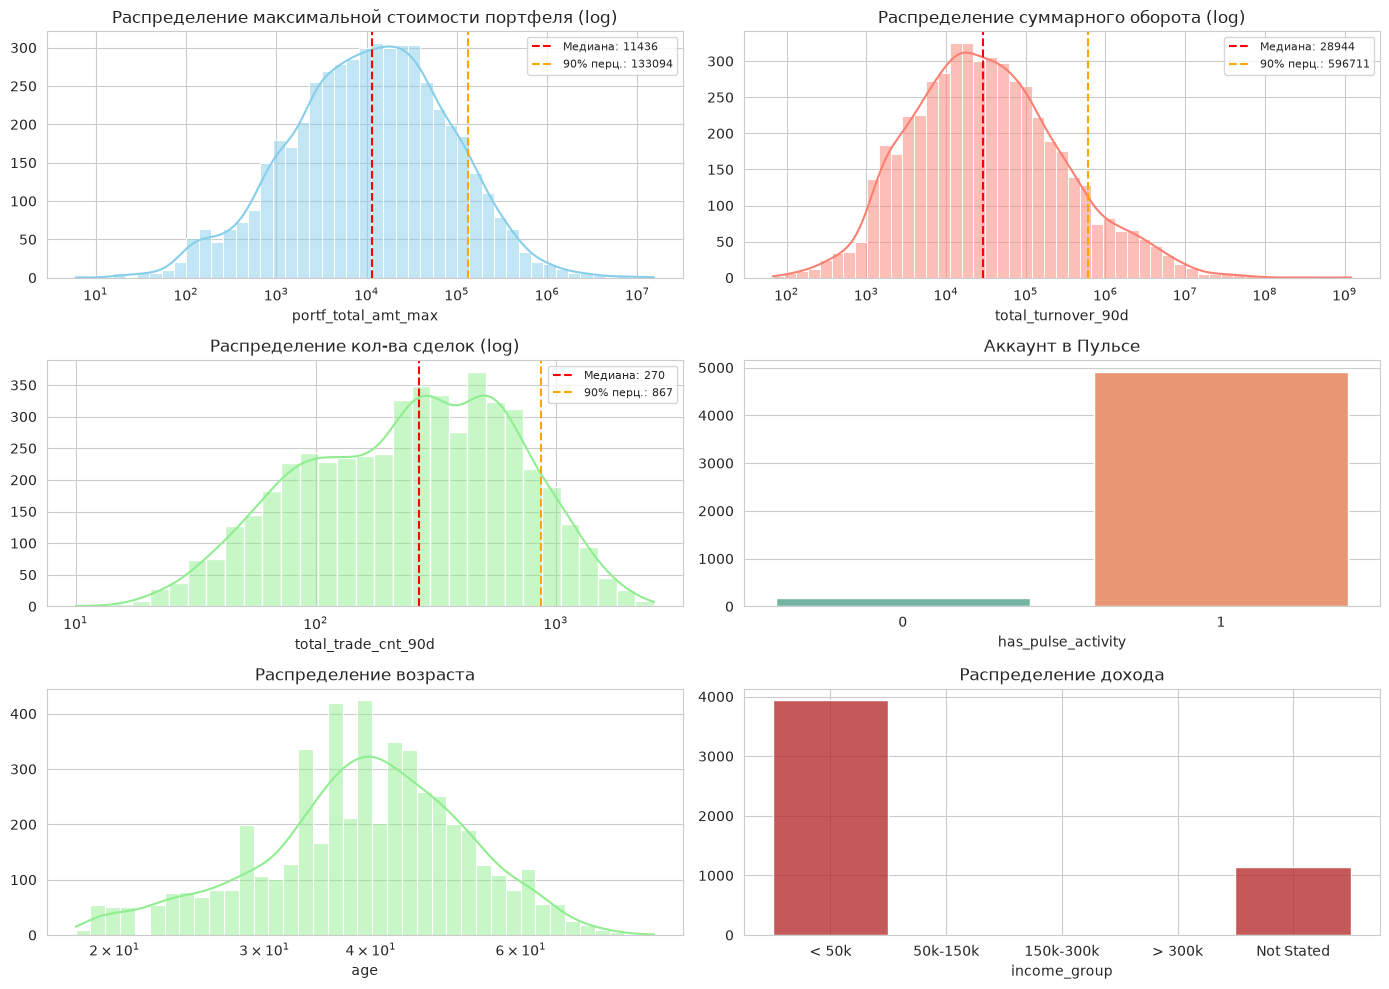

In [80]:

fig, axes = plt.subplots(3, 2, figsize=(14, 10))
sns.histplot(users["portf_total_amt_max"], kde=True, ax=axes[0, 0], log_scale=True, color="skyblue")
axes[0, 0].set_title("Распределение максимальной стоимости портфеля (log)")
axes[0, 0].set_ylabel("")

sns.histplot(users["total_turnover_90d"], kde=True, ax=axes[0, 1], log_scale=True, color="salmon")
axes[0, 1].set_title("Распределение суммарного оборота (log)")
axes[0, 1].set_ylabel("")


sns.histplot(users["total_trade_cnt_90d"], kde=True, ax=axes[1, 0], log_scale=True, color="lightgreen")
axes[1, 0].set_title("Распределение кол-ва сделок (log)")
axes[1, 0].set_ylabel("")


sns.countplot(data=users, x="has_pulse_activity", ax=axes[1, 1], palette="Set2")
axes[1, 1].set_title("Аккаунт в Пульсе")
axes[1, 1].set_ylabel("")

sns.histplot(users["age"], kde=True, ax=axes[2, 0], log_scale=True, color="lightgreen")
axes[2, 0].set_title("Распределение возраста")
axes[2, 0].set_ylabel("")

sns.histplot(users["income_group"], kde=False, ax=axes[2, 1], log_scale=True, color="firebrick")
axes[2, 1].set_title("Распределение дохода")
axes[2, 1].set_ylabel("")

for ax, col in zip(axes.flatten()[:3], ["portf_total_amt_max", "total_turnover_90d", "total_trade_cnt_90d"]):
    median = users[col].median()
    p90 = users[col].quantile(0.9)
    ax.axvline(median, color="red", linestyle="--", label=f"Медиана: {median:.0f}")
    ax.axvline(p90, color="orange", linestyle="--", label=f"90% перц.: {p90:.0f}")
    ax.legend(fontsize=8)


plt.tight_layout()
plt.show()

In [81]:
group1_cols = [
    "age",
    "monthly_income_amt",
    "children_cnt",
    "qualified_investor_flg",
    "forts_flg",
    "margin_status_flg",
    "uncovered_position_amt_abs_max"]

group2_cols = [
    "posts",
    "comments",
    "reacts",
    "reads",
    "turnover_tracking_amt",
    "trade_order_tracking_cnt",
    "turnover_rus_sec_amt",
    "trade_order_rus_sec_cnt"]

group3_cols = [
    "cor_balance_amt_max",
    "ccr_balance_amt_max",
    "lon_balance_amt_max",
    "in_payment_rub_amt",
    "out_payment_rub_amt",
    "portf_total_amt_max"]

group4_cols = [
    "turnover_rus_sec_amt",
    "turnover_rus_bon_amt",
    "turnover_fnd_amt",
    "turnover_forts_amt",
    "turnover_opt_amt",
    "turnover_ore_prc_amt"]

titles = ["Соцдем & Склонность к рисковым инструментам", "Активность в Пульсе & Торговля и Автоследование",
          "Банковский капитал и Ликвидность & Пополнения и Портфель", "Взаимосвязь оборотов по разным типам активов"]

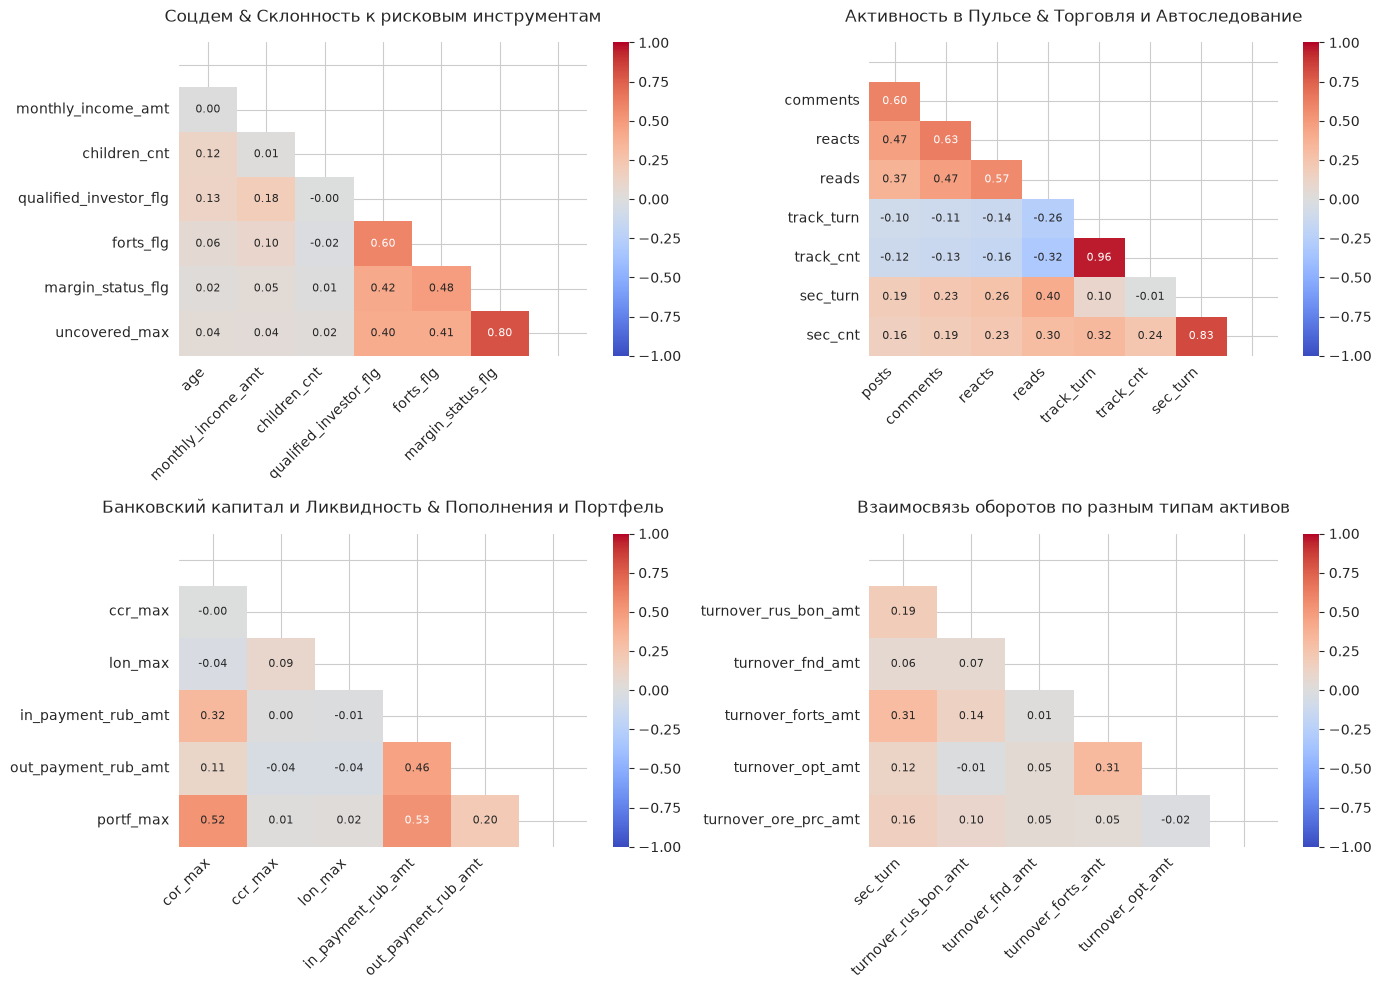

In [82]:
rename_map = {
    "uncovered_position_amt_abs_max": "uncovered_max",
    "cor_balance_amt_max": "cor_max",
    "ccr_balance_amt_max": "ccr_max",
    "lon_balance_amt_max": "lon_max",
    "portf_total_amt_max": "portf_max",
    "turnover_tracking_amt": "track_turn",
    "trade_order_tracking_cnt": "track_cnt",
    "turnover_rus_sec_amt": "sec_turn",
    "trade_order_rus_sec_cnt": "sec_cnt"}

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
ax = axes.flatten()

for i, n in enumerate([group1_cols, group2_cols, group3_cols, group4_cols]):

    corr = users[n].corr(method="spearman")
    corr.columns = [c if c not in rename_map else rename_map[c] for c in corr.columns]
    corr.index = [c if c not in rename_map else rename_map[c] for c in corr.index]

    mask = np.triu(np.ones_like(corr, dtype= bool))
    sns.heatmap(corr, mask=mask, annot=True, fmt = ".2f", ax=ax[i], cmap="coolwarm", vmin=-1, vmax=1, annot_kws={"size": 8})
    ax[i].set_title(titles[i], pad = 15)

    xlabels = ax[i].get_xticklabels()
    xlabels[-1] = ""

    ylabels = ax[i].get_yticklabels()
    ylabels[0] = ""

    ax[i].set_xticklabels(xlabels, rotation = 45, ha = "right", fontsize =10)
    ax[i].set_yticklabels(ylabels, fontsize =10)


plt.tight_layout()

### Предварительные выводы

- Портфель и оборот имеют классическое хэви-тейл распределение. Медиана сильно левее 90-го перцентиля: большинство клиентов маленькие, есть жирный хвост ценных.
- Почти у всех есть аккаунт в Пульсе (has_pulse_activity = 1 доминирует). Это хорошо — социальная механика охватная.
- Использование продвинутых инструментов (срочный рынок, маржа, статус квала) образует плотный блок. Соцдем на это почти не влияет.
- Активность в Пульсе — самостоятельный сильный кластер, слабо связанный с автоследованием.
- Размер брокерского портфеля связан с дебетовыми остатками и пополнениями, но почти не связан с кредитными/заёмными средствами.
- Обороты по разным классам активов слабо коррелируют между собой — клиенты в основном специализируются.

In [83]:
cluster_features = [
    "log_total_turnover_90d",
    "log_portf_total_amt_max",
    "advanced_tools",
    "log_total_trade_cnt_90d",
    "share_forts",
    "share_sec",
    "reads",                 
    "tenure_days",
    "has_pulse_activity"
]

users[cluster_features] = users[cluster_features].fillna(0)

X = users[cluster_features].copy()

In [84]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

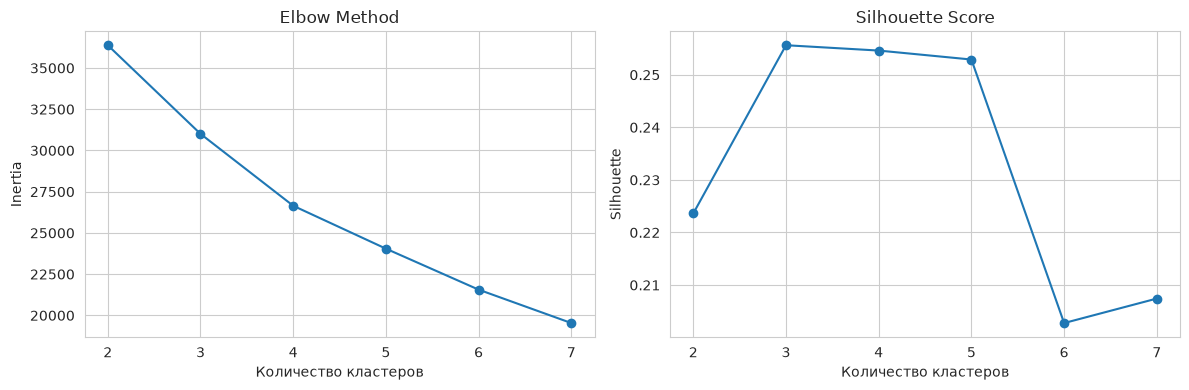

In [85]:
inertia = []
silhouette = []
K_range = range(2, 8)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    inertia.append(kmeans.inertia_)
    silhouette.append(silhouette_score(X_scaled, labels))

fig, ax = plt.subplots(1, 2, figsize=(12, 4))

ax[0].plot(K_range, inertia, "o-")
ax[0].set_title("Elbow Method")
ax[0].set_xlabel("Количество кластеров")
ax[0].set_ylabel("Inertia")

ax[1].plot(K_range, silhouette, "o-")
ax[1].set_title("Silhouette Score")
ax[1].set_xlabel("Количество кластеров")
ax[1].set_ylabel("Silhouette")

plt.tight_layout()
plt.show()

Оптимально - 3 кластера

In [86]:
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
users["cluster"] = kmeans.fit_predict(X_scaled)

In [87]:
profile = users.groupby("cluster").agg({
    "total_turnover_90d": "mean",
    "portf_total_amt_max": "mean",
    "advanced_tools": "mean",
    "forts_flg": "mean",
    "margin_status_flg": "mean",
    "qualified_investor_flg": "mean",
    "total_trade_cnt_90d": "mean",
    "reads": "mean",
    "tenure_days": "mean",
    "age": "mean",
    "id": "count"
}).rename(columns={"id": "size"}).round(2)

profile["size_pct"] = (profile["size"] / len(users) * 100).round(1)

profile = profile.sort_values("total_turnover_90d", ascending=False)
profile

,total_turnover_90d,portf_total_amt_max,advanced_tools,forts_flg,margin_status_flg,qualified_investor_flg,total_trade_cnt_90d,reads,tenure_days,age,size,size_pct
cluster,,,,,,,,,,,,
0,1968419.97,161481.39,2.40,0.95,0.70,0.75,527.12,716.36,1164.51,42.05,1925,37.80
1,57295.03,11315.85,0.16,0.07,0.06,0.03,368.55,0.00,269.47,44.53,180,3.50
2,28011.63,15180.96,0.53,0.33,0.16,0.04,290.20,163.50,798.97,39.32,2988,58.70


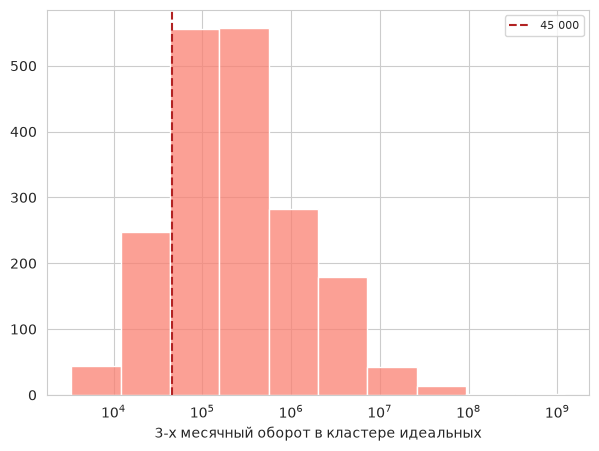

In [88]:
fig = plt.figure(figsize=(7, 5))
ax = sns.histplot(users[users["cluster"] == 0]["total_turnover_90d"], bins=10, log_scale=True, color="salmon")
ax.set_ylabel("")
ax.set_xlabel("3-х месячный оборот в кластере идеальных")

ax.axvline(45000, color="firebrick", linestyle="--", label= "45 000")
ax.legend(fontsize=8)
plt.show()

In [89]:
turnover_thr = users.query("cluster ==0")['total_turnover_90d'].quantile(0.25)
portf_thr = users.query("cluster ==0")['portf_total_amt_max'].quantile(0.25)

users['is_ideal'] = (
    (users['cluster'] == 0) & 
    (users['total_turnover_90d'] >= turnover_thr) &
    (users['portf_total_amt_max'] >= portf_thr)
).astype(int)

In [90]:
compare_cols = [
    "total_turnover_90d", "portf_total_amt_max", "advanced_tools",
    "forts_flg", "margin_status_flg", "qualified_investor_flg",
    "total_trade_cnt_90d", "reads", "age", "is_ideal"]

profile_2 = users.query("cluster == 0").groupby("is_ideal").agg(dict(zip(compare_cols, ["mean"]*(len(compare_cols)-1) + ["count"]))).rename(columns={"is_ideal":"size"})
profile_2["size_pct"] = profile_2["size"] / len(users.query("cluster == 0"))
profile_2

,total_turnover_90d,portf_total_amt_max,advanced_tools,forts_flg,margin_status_flg,qualified_investor_flg,total_trade_cnt_90d,reads,age,size,size_pct
is_ideal,,,,,,,,,,,
0,311811.81,49668.56,2.38,0.96,0.73,0.68,439.50,817.33,41.08,816,0.42
1,3187348.96,243753.05,2.41,0.93,0.68,0.80,591.59,642.08,42.76,1109,0.58


In [91]:
profile = users.groupby("is_ideal").agg({
    "total_turnover_90d": "mean",
    "portf_total_amt_max": "mean",
    "turnover_tracking_amt": "mean",
    "advanced_tools": "mean",
    "forts_flg": "mean",
    "margin_status_flg": "mean",
    "qualified_investor_flg": "mean",
    "total_trade_cnt_90d": "mean",
    "reads": "mean",
    "tenure_days": "mean",
    "age": "mean",
    "id": "count"
}).rename(columns={"id": "size"}).round(2)

profile["size_pct"] = (profile["size"] / len(users) * 100).round(1)

profile = profile.sort_values("total_turnover_90d", ascending=False)
profile

,total_turnover_90d,portf_total_amt_max,turnover_tracking_amt,advanced_tools,forts_flg,margin_status_flg,qualified_investor_flg,total_trade_cnt_90d,reads,tenure_days,age,size,size_pct
is_ideal,,,,,,,,,,,,,
1,3187348.96,243753.05,51288.23,2.41,0.93,0.68,0.80,591.59,642.08,1192.94,42.76,1109,21.80
0,87462.42,22070.05,5354.51,0.89,0.45,0.27,0.17,324.32,290.03,842.00,39.91,3984,78.20


In [92]:
X_pca = users[cluster_features]

scaler_pca = StandardScaler()
X_pca_scaled = scaler_pca.fit_transform(X_pca)

pca = PCA(n_components=2, random_state=42)
pca_result = pca.fit_transform(X_pca_scaled)

users['pca_1'] = pca_result[:, 0]
users['pca_2'] = pca_result[:, 1]

print(f"Доля объяснённой дисперсии: {pca.explained_variance_ratio_.sum():.1%}")
print(f"1-я компонента: {pca.explained_variance_ratio_[0]:.1%}")
print(f"2-я компонента: {pca.explained_variance_ratio_[1]:.1%}")

Доля объяснённой дисперсии: 45.9%
1-я компонента: 31.2%
2-я компонента: 14.7%


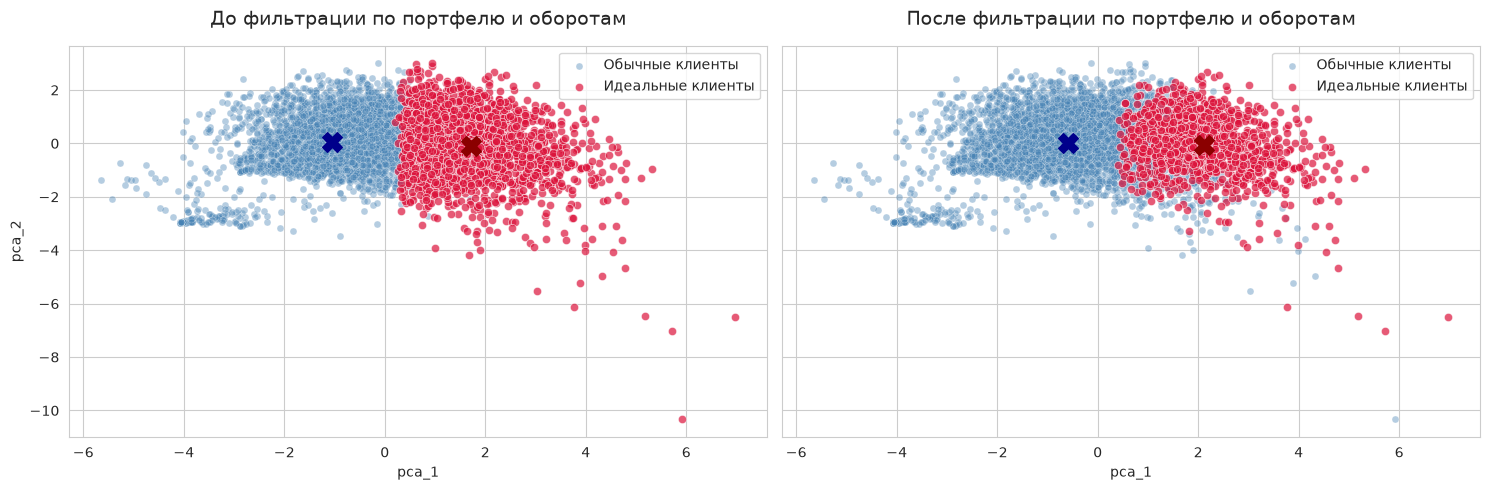

In [93]:
fig, axes = plt.subplots(1,2, figsize=(15, 5), sharey=True)

sns.scatterplot(
    data=users[users["cluster"] != 0],
    x="pca_1", y="pca_2",
    color="steelblue", alpha=0.4, s=25,
    label="Обычные клиенты",
    ax = axes[0] )

sns.scatterplot(
    data=users[users["cluster"] == 0],
    x="pca_1", y="pca_2",
    color="crimson", alpha=0.7, s=35,
    label="Идеальные клиенты",
    ax = axes[0] )

sns.scatterplot(
    data=users[users["is_ideal"] == 0],
    x="pca_1", y="pca_2",
    color="steelblue", alpha=0.4, s=25,
    label="Обычные клиенты",
    ax = axes[1] )

sns.scatterplot(
    data=users[users["is_ideal"] == 1],
    x="pca_1", y="pca_2",
    color="crimson", alpha=0.7, s=35,
    label="Идеальные клиенты",
    ax = axes[1] )

ideal_center0 = users[users["cluster"] == 0][["pca_1", "pca_2"]].mean()
ordinary_center0 = users[users["cluster"] != 0][["pca_1", "pca_2"]].mean()

ideal_center1 = users[users["is_ideal"] == 1][["pca_1", "pca_2"]].mean()
ordinary_center1 = users[users["is_ideal"] == 0][["pca_1", "pca_2"]].mean()


axes[0].scatter(ideal_center0["pca_1"], ideal_center0["pca_2"], 
            color="darkred", s=200, marker="X", zorder=5)
axes[0].scatter(ordinary_center0["pca_1"], ordinary_center0["pca_2"], 
            color="darkblue", s=200, marker="X", zorder=5)


axes[1].scatter(ideal_center1["pca_1"], ideal_center1["pca_2"], 
            color="darkred", s=200, marker="X", zorder=5)
axes[1].scatter(ordinary_center1["pca_1"], ordinary_center1["pca_2"], 
            color="darkblue", s=200, marker="X", zorder=5)



axes[0].set_title("До фильтрации по портфелю и оборотам", fontsize=14, pad=15)
axes[1].set_title("После фильтрации по портфелю и оборотам", fontsize=14, pad=15)

plt.legend()
plt.tight_layout()
plt.show()

### Определение идеального клиента

Идеальный клиент — это представитель наиболее ценного кластера (кластер 0), у которого оборот и размер портфеля находятся не ниже 25-го перцентиля внутри этого кластера.

Ключевые характеристики:
- Высокие обороты и крупный портфель
- Активное использование срочного рынка, маржинальной торговли и статуса квалифицированного инвестора
- Повышенная вовлечённость в Пульс

Доля в выборке: **21,8%**.

In [94]:
final_compare = users.groupby("is_ideal").agg({
    "total_turnover_90d": "mean",
    "portf_total_amt_max": "mean",
    "advanced_tools": "mean",
    "forts_flg": "mean",
    "margin_status_flg": "mean",
    "qualified_investor_flg": "mean",
    "total_trade_cnt_90d": "mean",
    "reads": "mean",
    "age": "mean",
    "tenure_days": "mean",
    "id": "count"
}).rename(columns={"id": "size"}).round(2)

final_compare["size_pct"] = (final_compare["size"] / len(users) * 100).round(1)
final_compare

,total_turnover_90d,portf_total_amt_max,advanced_tools,forts_flg,margin_status_flg,qualified_investor_flg,total_trade_cnt_90d,reads,age,tenure_days,size,size_pct
is_ideal,,,,,,,,,,,,
0,87462.42,22070.05,0.89,0.45,0.27,0.17,324.32,290.03,39.91,842.00,3984,78.20
1,3187348.96,243753.05,2.41,0.93,0.68,0.80,591.59,642.08,42.76,1192.94,1109,21.80


In [95]:
from scipy.stats import mannwhitneyu, chi2_contingency

ideal = users[users["is_ideal"] == 1]
ordinary = users[users["is_ideal"] == 0]

# Непрерывные признаки
cont_cols = [
    "total_turnover_90d", "portf_total_amt_max", 
    "total_trade_cnt_90d", "reads", "age", "tenure_days"
]

print("Манна-Уитни:")
for col in cont_cols:
    stat, p = mannwhitneyu(ideal[col], ordinary[col], alternative="two-sided")
    print(f"{col:25} | p-value = {p:.2e}")

# Бинарные признаки
print("\nХи-квадрат")
for col in ["forts_flg", "margin_status_flg", "qualified_investor_flg"]:
    table = pd.crosstab(users["is_ideal"], users[col])
    chi2, p, _, _ = chi2_contingency(table)
    print(f"{col:25} | Ideal: {ideal[col].mean():.1%} | Ordinary: {ordinary[col].mean():.1%} | p = {p:.2e}")

Манна-Уитни:
total_turnover_90d        | p-value = 0.00e+00
portf_total_amt_max       | p-value = 0.00e+00
total_trade_cnt_90d       | p-value = 2.16e-87
reads                     | p-value = 2.56e-72
age                       | p-value = 1.29e-15
tenure_days               | p-value = 4.22e-78

Хи-квадрат
forts_flg                 | Ideal: 93.3% | Ordinary: 44.9% | p = 1.72e-180
margin_status_flg         | Ideal: 67.9% | Ordinary: 27.0% | p = 6.74e-139
qualified_investor_flg    | Ideal: 80.0% | Ordinary: 17.0% | p = 0.00e+00


In [96]:
def compare(col):
    ct = pd.crosstab(users["is_ideal"], users[col], normalize='index') * 100
    return ct.round(1)

for name, col in zip(["Образование","Семейное положение","Группа дохода"], ["education_level_cd", "marital_status_cd", "income_group"]):
    print(name)
    display(compare(col))


Образование


education_level_cd,ACD,GRD,MGR,PGR,SCH,UGR,UNK
is_ideal,,,,,,,
0,0.50,29.30,0.00,1.50,11.60,7.10,49.90
1,1.00,38.20,0.00,3.40,5.50,6.00,45.90


Семейное положение


marital_status_cd,CIV,DIV,MAR,UNK,UNM,WID
is_ideal,,,,,,
0,4.50,4.50,27.40,42.10,21.20,0.40
1,4.30,4.00,31.70,40.60,18.80,0.50


Группа дохода


income_group,< 50k,50k-150k,150k-300k,Not Stated
is_ideal,,,,
0,77.70,0.10,0.00,22.30
1,75.90,0.50,0.10,23.40


In [97]:
print("Возраст и дети")
users.groupby('is_ideal')[['age', 'children_cnt']].agg(['mean', 'median']).round(2)

Возраст и дети


age        children_cnt       
          mean median         mean median
is_ideal                                 
0        39.91  39.00         0.06   0.00
1        42.76  42.00         0.06   0.00

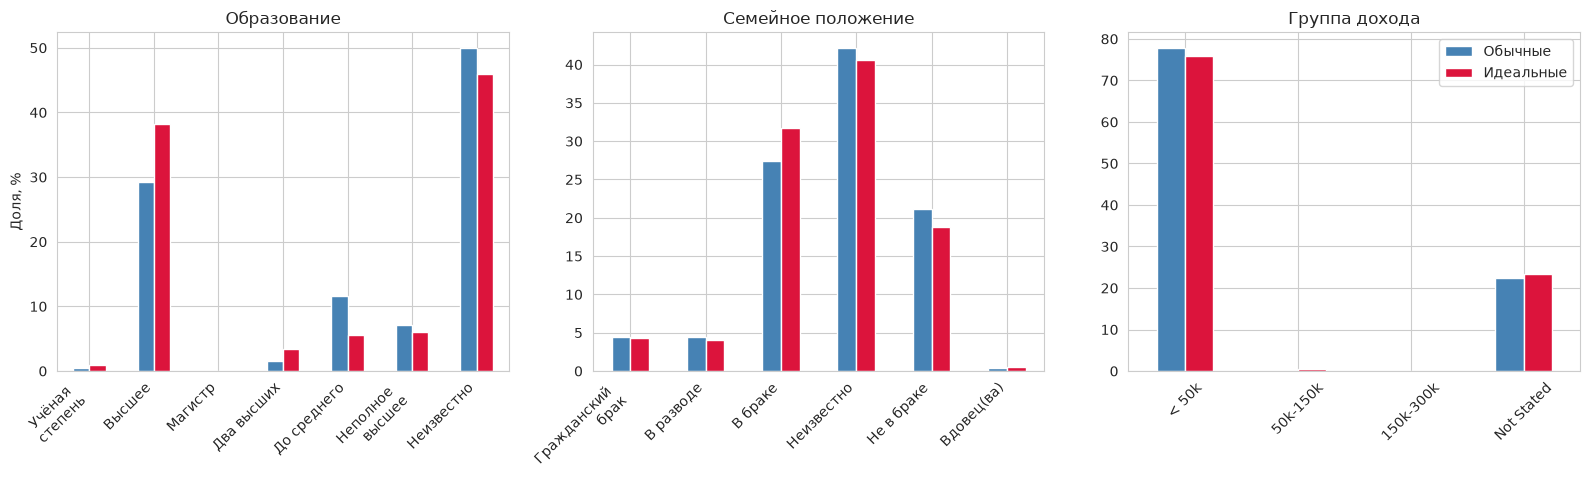

In [98]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

edu = compare("education_level_cd").T
edu.plot(kind="bar", ax=axes[0], color=["steelblue", "crimson"])
axes[0].set_title("Образование")
axes[0].set_ylabel("Доля, %")
axes[0].legend().set_visible(False)
axes[0].tick_params(axis="x", rotation=45)

mar = compare("marital_status_cd").T
mar.plot(kind="bar", ax=axes[1], color=["steelblue", "crimson"])
axes[1].set_title("Семейное положение")
axes[1].legend().set_visible(False)
axes[1].tick_params(axis="x", rotation=45)

inc = compare("income_group").T
inc.plot(kind="bar", ax=axes[2], color=["steelblue", "crimson"])
axes[2].set_title("Группа дохода")
axes[2].legend(["Обычные", "Идеальные"])
axes[2].tick_params(axis="x", rotation=45)

axes[0].set_xticklabels(["Учёная \nстепень", "Высшее", "Магистр", "Два высших", "До среднего", "Неполное \nвысшее", "Неизвестно"], ha = "right", fontsize = 10)
axes[1].set_xticklabels(["Гражданский \nбрак", "В разводе", "В браке", "Неизвестно", "Не в браке", "Вдовец(ва)"], ha = "right", fontsize = 10)

axes[0].set_xlabel("")
axes[1].set_xlabel("")
axes[2].set_xlabel("")


plt.tight_layout()
plt.show()

### Идеальный клиент (21.8% выборки):

- Средний оборот за 3 месяца ~ 3.19 млн руб. (примерно в 36 раз выше обычных)
- Средний максимальный портфель ~ 244 тыс. руб.

**Активно использует продвинутые инструменты:**
- 93% — *срочный рынок*
- 68% — *маржинальная торговля*
- *80% — статус квалифицированного инвестора*

Заметно выше активность в Пульсе                               
В среднем немного старше (43 года)                       
Чаще имеет высшее образование                             
Чуть чаще состоит в браке                      
Дольше находится на платформе

**Социально-демографические различия есть, но они слабые по сравнению с поведенческими (оборот, портфель, advanced tools).**

## Продуктовые гипотезы


**Развитие Пульса и образовательного контента**                              
Идеальные клиенты значительно активнее потребляют контент.
Вовлечение в коммьюнити и обучение может повышать конверсию в ценных клиентов.

**Упрощение доступа к продвинутым инструментам**                                
Использование маржи, срочного рынка и статуса квала — сильный маркер ценности.
Точечные предложения и обучение этим продуктам перспективным клиентам из среднего сегмента.

**Фокус на раннем удержании**                                      
Идеальные клиенты в среднем дольше на платформе.
Качество онбординга в первые месяцы критично влияет на вероятность вырасти в ценного клиента.